In [11]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for Obsidian-friendly clean looks
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [12]:
# Load cleaned feature dataset
df = pd.read_csv("../data/processed/transactions_features.csv")

In [13]:
# Target and core columns based on header
target_col = "is_fraud"

In [14]:
# Map one-hot encoded payment_method_* into a single category label
def decode_payment_method(row):
    for col in ["payment_method_CARD", "payment_method_NETBANKING",
                "payment_method_UPI", "payment_method_WALLET"]:
        if col in row and row[col] == 1:
            return col.replace("payment_method_", "")
    return "OTHER"

def decode_merchant_category(row):
    for col in ["merchant_category_Electronics", "merchant_category_Fashion",
                "merchant_category_Gaming", "merchant_category_Grocery",
                "merchant_category_Travel", "merchant_category_Utilities"]:
        if col in row and row[col] == 1:
            return col.replace("merchant_category_", "")
    return "OTHER"

df["payment_method"] = df.apply(decode_payment_method, axis=1)
df["merchant_category"] = df.apply(decode_merchant_category, axis=1)

C:\Users\Punk\AppData\Local\Temp\ipykernel_10144\1623288367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


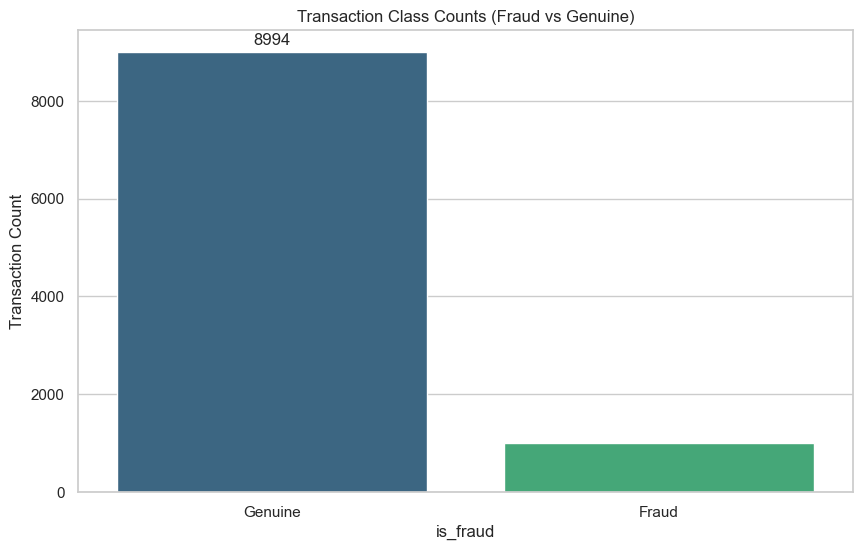

In [15]:
# --- 1) Class Balance Bar Chart ---
from matplotlib.container import BarContainer
from typing import cast

plt.figure()
class_counts = df[target_col].value_counts().rename({0: "Genuine", 1: "Fraud"})
ax1 = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

plt.title("Transaction Class Counts (Fraud vs Genuine)")
plt.ylabel("Transaction Count")

# MODERN FIX: Automatically add labels to the bars (cast to satisfy type checker)
ax1.bar_label(cast(BarContainer, ax1.containers[0]), padding=3)

plt.savefig("../reports/class_balance.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_10144\3046888062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pm.index, y=pm.values, palette="magma")


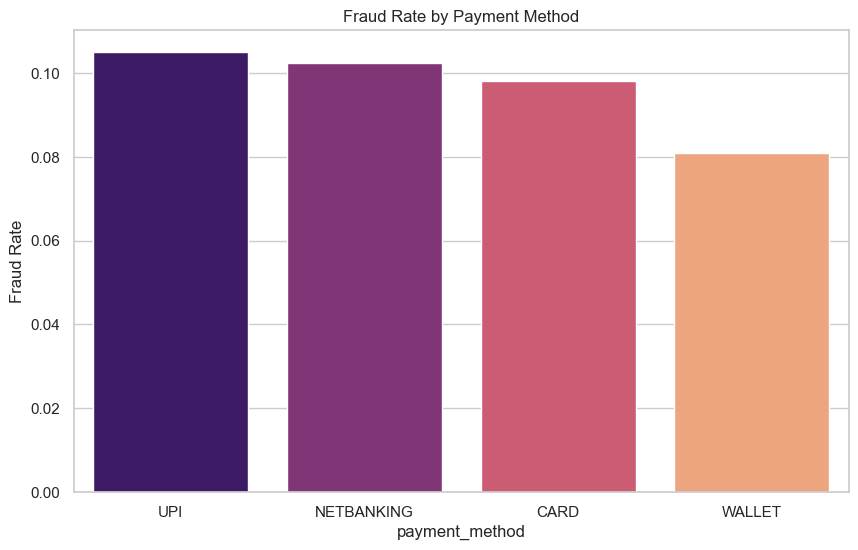

In [16]:
# --- 2) Fraud Rate by Payment Method ---
plt.figure()
pm = df.groupby("payment_method")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=pm.index, y=pm.values, palette="magma")
plt.title("Fraud Rate by Payment Method")
plt.ylabel("Fraud Rate")
plt.savefig("../reports/fraud_rate_payment.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_10144\2766015192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mc.index, y=mc.values, palette="rocket")


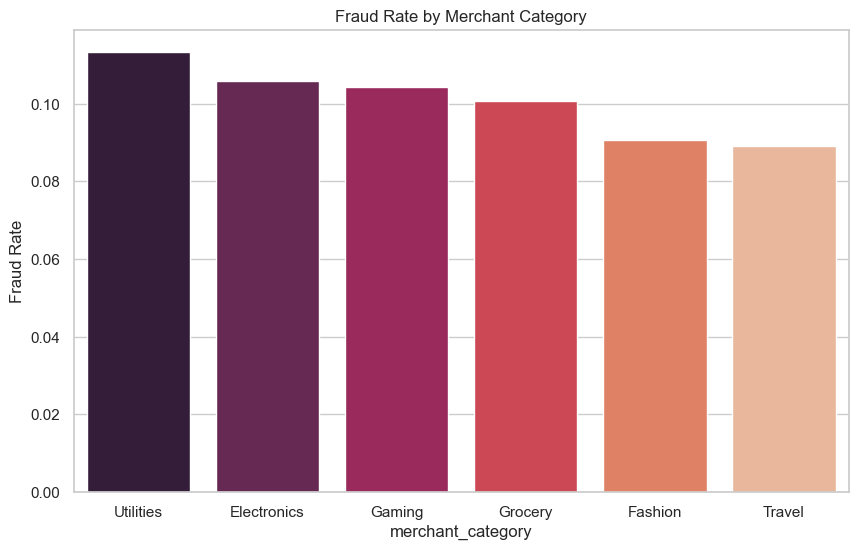

In [17]:
# --- 3) Fraud Rate by Merchant Category ---
plt.figure()
mc = df.groupby("merchant_category")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=mc.index, y=mc.values, palette="rocket")
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.savefig("../reports/fraud_rate_merchant.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_10144\483918030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y="amount", inner="quartile", palette="Set2")


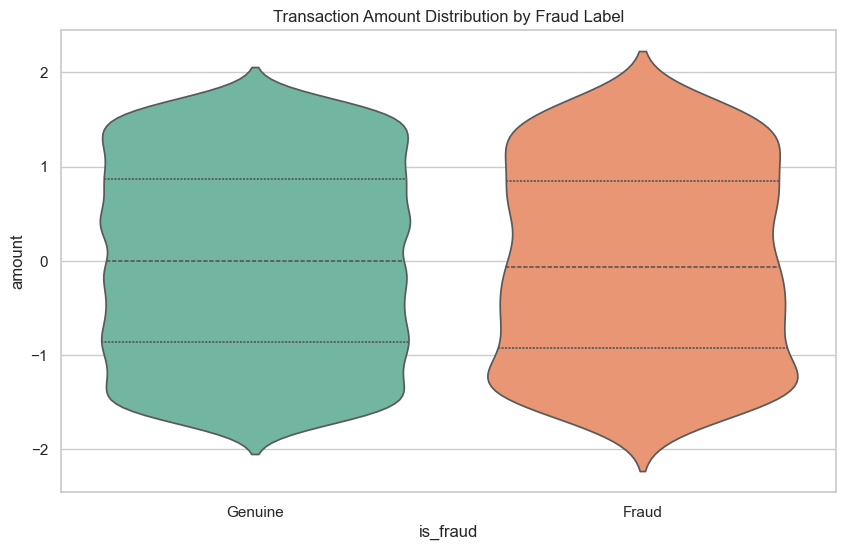

In [18]:
# --- 4) Amount Distribution (Violin Plot) ---
plt.figure()
sns.violinplot(data=df, x=target_col, y="amount", inner="quartile", palette="Set2")
plt.title("Transaction Amount Distribution by Fraud Label")
plt.xticks([0, 1], ["Genuine", "Fraud"])
plt.savefig("../reports/amount_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

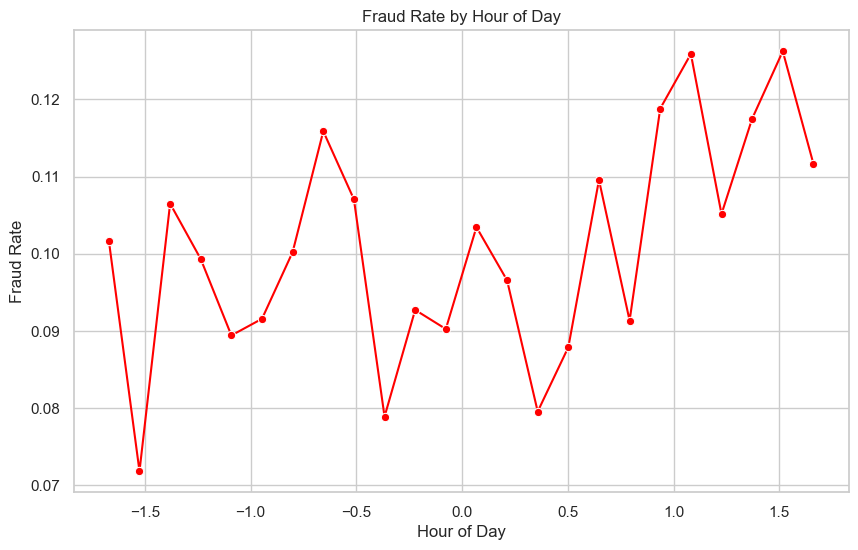

In [19]:
# --- 5) Fraud Rate by Time of Day ---
if "time_of_day" in df.columns:
    plt.figure()
    hr = df.groupby("time_of_day")[target_col].mean()
    sns.lineplot(x=hr.index, y=hr.values, marker="o", color="red")
    plt.title("Fraud Rate by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate")
    plt.savefig("../reports/fraud_rate_time.png", dpi=300, bbox_inches='tight')
    plt.show()

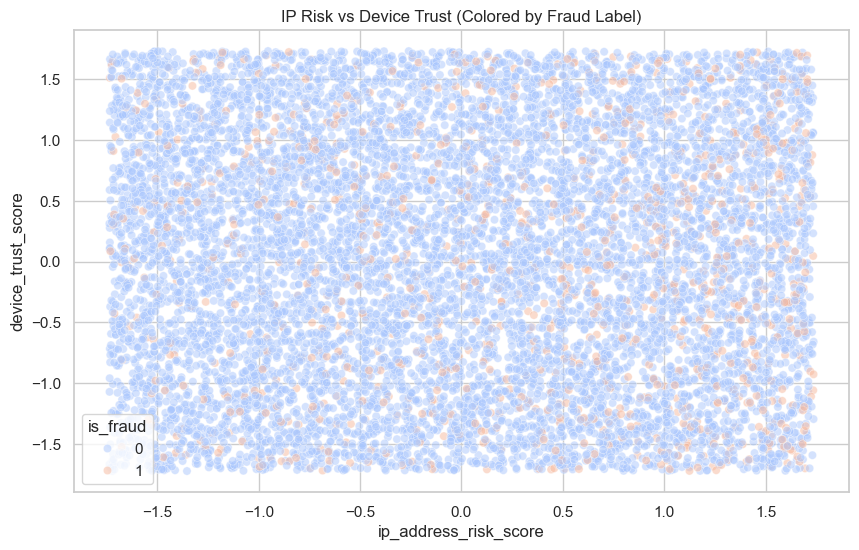

In [20]:
# --- 6) IP Risk vs Device Trust Scatter ---
if {"ip_address_risk_score", "device_trust_score"}.issubset(df.columns):
    plt.figure()
    sample = df.sample(min(len(df), 20000), random_state=42)
    sns.scatterplot(
        data=sample, 
        x="ip_address_risk_score", 
        y="device_trust_score", 
        hue=target_col, 
        alpha=0.5,
        palette="coolwarm"
    )
    plt.title("IP Risk vs Device Trust (Colored by Fraud Label)")
    plt.savefig("../reports/risk_vs_trust.png", dpi=300, bbox_inches='tight')
    plt.show()